In [ ]:
#Building a Basic chatbot with Langgraph(Graph Api)

#Componets of the langgraph.
'''
Edges
Nodes
State


Yt videos -> Blog.
#Workflow.
Yt Videos -> Transcription.
Transcription -> Title, Summary, Keywords, Tags, Description.
Title, Transcription, Summary, Keywords, Tags, Description -> Content Creation.
'''

#Graph Api.
#Functional Api.

#Yt URL <start> -> Transcription -> Title Generator -> Content Generator -> <end> o/p.


In [1]:
from typing import Annotated, TypedDict
from typing_extensions import TypedDict

from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages

In [ ]:
#Reducers add the messages to the graph. Instead of replace the previous messages. 
#Reducers name is add_messages.

In [2]:
class State(TypedDict):
    #Mesages have the type "list". The 'add_messages' function.
    #In the annotation defines how this state key shouold be updated.
    #In this case. it append to the list, rather than overwriting the previous messages.
    messages: Annotated[list, add_messages]

graph_builder = StateGraph(State)


In [3]:
graph_builder

In [4]:
#Build the entire graph.
import os
from dotenv import load_dotenv
load_dotenv()


True

In [5]:
from langchain_groq import ChatGroq
from langchain.chat_models import init_chat_model

llm = ChatGroq(model = "openai/gpt-oss-20b")

In [6]:
llm

ChatGroq(metadata={'lc_versions': {'langchain-core': '1.6.0', 'langchain': '1.3.16'}}, profile={'name': 'GPT OSS 20B', 'release_date': '2025-08-05', 'last_updated': '2026-05-27', 'open_weights': True, 'max_input_tokens': 131072, 'max_output_tokens': 65536, 'text_inputs': True, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': True, 'tool_calling': True, 'structured_output': True, 'attachment': False, 'temperature': True}, client=<groq.resources.chat.completions.Completions object at 0x00000286A5774DD0>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x00000286A58D49D0>, model_name='openai/gpt-oss-20b', model_kwargs={}, groq_api_key=SecretStr('**********'))

In [7]:
llm = init_chat_model("groq:openai/gpt-oss-20b")
llm

ChatGroq(metadata={'lc_versions': {'langchain-core': '1.6.0', 'langchain': '1.3.16'}}, profile={'name': 'GPT OSS 20B', 'release_date': '2025-08-05', 'last_updated': '2026-05-27', 'open_weights': True, 'max_input_tokens': 131072, 'max_output_tokens': 65536, 'text_inputs': True, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': True, 'tool_calling': True, 'structured_output': True, 'attachment': False, 'temperature': True}, client=<groq.resources.chat.completions.Completions object at 0x00000286A58D6ED0>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x00000286A58D7C10>, model_name='openai/gpt-oss-20b', model_kwargs={}, groq_api_key=SecretStr('**********'))

In [8]:
#Node definition. # Node functionality.

def chatbot(state:State):
    return {"messages":[llm.invoke(state["messages"])]}


In [9]:
graph_builder = StateGraph(State)

#Adding the node to the graph.
graph_builder.add_node("llmchatbot",chatbot)

#Adding the edge to the graph.
graph_builder.add_edge(START,"llmchatbot")
graph_builder.add_edge("llmchatbot",END)

#Compile the graph.

graph = graph_builder.compile()

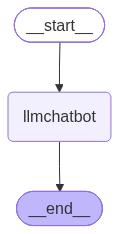

In [10]:
graph

In [11]:
response = graph.invoke({"messages":"Hi"})


In [12]:
response["messages"]

[HumanMessage(content='Hi', additional_kwargs={}, response_metadata={}, id='c082dae2-65be-4bd2-a761-df29830ff53a'),
 AIMessage(content='Hello! 👋 How can I help you today?', additional_kwargs={'reasoning_content': 'We need to respond to user greeting. Provide friendly greeting.'}, response_metadata={'token_usage': {'completion_tokens': 33, 'prompt_tokens': 72, 'total_tokens': 105, 'completion_time': 0.035550863, 'completion_tokens_details': {'reasoning_tokens': 13}, 'prompt_time': 0.003426467, 'prompt_tokens_details': None, 'queue_time': 0.283670313, 'total_time': 0.03897733}, 'model_name': 'openai/gpt-oss-20b', 'system_fingerprint': 'fp_24bfb4a850', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--01a03268-e16f-7ae3-921f-095f1d45296f-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 72, 'output_tokens': 33, 'total_tokens': 105, 'output_token_details': {'reasoning': 13}})]

In [13]:
response["messages"][-1]

AIMessage(content='Hello! 👋 How can I help you today?', additional_kwargs={'reasoning_content': 'We need to respond to user greeting. Provide friendly greeting.'}, response_metadata={'token_usage': {'completion_tokens': 33, 'prompt_tokens': 72, 'total_tokens': 105, 'completion_time': 0.035550863, 'completion_tokens_details': {'reasoning_tokens': 13}, 'prompt_time': 0.003426467, 'prompt_tokens_details': None, 'queue_time': 0.283670313, 'total_time': 0.03897733}, 'model_name': 'openai/gpt-oss-20b', 'system_fingerprint': 'fp_24bfb4a850', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--01a03268-e16f-7ae3-921f-095f1d45296f-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 72, 'output_tokens': 33, 'total_tokens': 105, 'output_token_details': {'reasoning': 13}})

In [14]:
for event in graph.stream({"messages":"Hi How are you?"}):
    for value in event.values():
        print(value)


{'messages': [AIMessage(content='Hi! I’m doing great—thanks for asking. How about you? 😊', additional_kwargs={'reasoning_content': "We need to respond. It's a casual greeting. Should respond politely."}, response_metadata={'token_usage': {'completion_tokens': 40, 'prompt_tokens': 76, 'total_tokens': 116, 'completion_time': 0.069447204, 'completion_tokens_details': {'reasoning_tokens': 15}, 'prompt_time': 0.006877646, 'prompt_tokens_details': None, 'queue_time': 0.306315824, 'total_time': 0.07632485}, 'model_name': 'openai/gpt-oss-20b', 'system_fingerprint': 'fp_66f3850a1a', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--01a03269-0aa5-7740-9340-81b1bc1d64c4-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 76, 'output_tokens': 40, 'total_tokens': 116, 'output_token_details': {'reasoning': 15}})]}


In [ ]:
#Integration with Tools.

#If the info not having the given documents.
#The LLM can use the tool to generate the response. 
#It can web search.


In [ ]:
#Chatbot with tools.
#tool valling llm is the firstnode.
#Tools like Tavily search, custom tools -> tool node.
#Every llm has the doc string -> string have the info in the form the text.


In [15]:
from langchain_tavily import TavilySearch

tool = TavilySearch(max_results = 2)
result = tool.invoke({"query": "What is the capital of France?"})

In [16]:
result

{'query': 'What is the capital of France?',
 'follow_up_questions': None,
 'answer': None,
 'images': [],
 'results': [{'url': 'https://www.britannica.com/place/France',
   'title': 'France | History, Maps, Flag, Population, Cities, Capital, & Facts',
   'content': "This answer is created from Britannica articles using AI. AI can make mistakes, so verify using Britannica articles. \n\n   What is the capital city of France and why is it famous?  \n\nThe capital of France is Paris. Situated in the north-central part of the country, Paris is France's center of commerce and culture. [...] The capital and by far the most important city of France is Paris, one of the world’s preeminent cultural and commercial centres. A majestic city known as the _ville lumière_, or “city of light,” Paris has often been remade, most famously in the mid-19th century under the command of Georges-Eugène, Baron Haussman, who was committed to Napoleon III’s vision of a modern city free of the choleric swamps and 

In [17]:
from langchain_tavily import TavilySearch

tool = TavilySearch(max_results = 2)
result = tool.invoke({"query": "Why langgraph is using for building the llm applications instead of langchain?"})

In [18]:
result

{'query': 'Why langgraph is using for building the llm applications instead of langchain?',
 'follow_up_questions': None,
 'answer': None,
 'images': [],
 'results': [{'url': 'https://www.truefoundry.com/blog/langchain-vs-langgraph',
   'title': 'LangChain vs LangGraph: Compare Features & Use Cases - Truefoundry',
   'content': 'Both LangChain and LangGraph are powerful tools for building LLM-powered applications, each excelling in different scenarios. LangChain is ideal for simpler, linear workflows that benefit from rapid prototyping and extensive integrations, while LangGraph is designed for complex, adaptive, and stateful agent systems. Choosing the right one depends on your project’s complexity and long-term goals. Regardless of your choice, pairing these frameworks with TrueFoundry as your AI Gateway ensures your [...] When you build with LangChain or LangGraph, you’re creating powerful LLM-powered workflows. But getting them to run reliably, cost-effectively, and securely in pro

In [44]:
##custom function.

def multiply(a:int,b:int):
    """
    Multiply two integers and return the result.

    Args:
        a (int): The first integer to multiply.
        b (int): The second integer to multiply.

    Returns:
        int: The product of the two integers.
    """
    return a * b
    

In [45]:
tools = [tool, multiply]

In [46]:
llm_with_tool = llm.bind_tools(tools)


In [47]:
llm_with_tool

_ChatModelBinding(bound=ChatGroq(metadata={'lc_versions': {'langchain-core': '1.6.0', 'langchain': '1.3.16'}}, profile={'name': 'GPT OSS 20B', 'release_date': '2025-08-05', 'last_updated': '2026-05-27', 'open_weights': True, 'max_input_tokens': 131072, 'max_output_tokens': 65536, 'text_inputs': True, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': True, 'tool_calling': True, 'structured_output': True, 'attachment': False, 'temperature': True}, client=<groq.resources.chat.completions.Completions object at 0x00000286A58D6ED0>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x00000286A58D7C10>, model_name='openai/gpt-oss-20b', model_kwargs={}, groq_api_key=SecretStr('**********')), kwargs={'tools': [{'type': 'function', 'function': {'name': 'tavily_search', 'description': 'A search engine optimized for comprehensive, accurate, and

In [65]:
from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode, tools_condition


# Node definition
def tool_calling_llm(state: State):
    return {
        "messages": [
            llm_with_tool.invoke(state["messages"])
        ]
    }


# Create graph
builder = StateGraph(State)


# Add nodes
builder.add_node("tool_calling_llm", tool_calling_llm)
builder.add_node("tools", ToolNode(tools))


# START → LLM
builder.add_edge(START, "tool_calling_llm")


# LLM → either tools OR END
builder.add_conditional_edges(
    "tool_calling_llm",
    tools_condition,
)


# Tools → LLM
builder.add_edge("tools", END)


# Compile
graph = builder.compile()

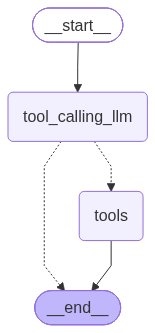

In [66]:
graph

In [67]:
response = graph.invoke({"messages": [{"role": "user", "content": "What is the recent ai news?"}]})

In [68]:
response["messages"][-1]

ToolMessage(content='{"query": "AI news August 2026", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://www.marketingprofs.com/opinions/2026/55655/ai-update-august-21-2026-ai-news-and-views-from-the-past-two-weeks", "title": "AI Update, August 21, 2026: AI News and Views From the ...", "content": "SpaceX and Meta close the gap on OpenAI and Anthropic in AI race. SpaceX and Meta have re-emerged as serious contenders in frontier AI after releasing models that combine stronger performance with aggressive pricing. Grok 4.6 scored roughly even with OpenAI\'s GPT-5.6 Sol Max on a prominent benchmark, while Meta\'s Muse Glimmer offers competitive performance at far lower cost and can run locally on a laptop. Both companies have poured billions into talent, infrastructure, acquisitions, and proprietary data after previously lagging OpenAI and Anthropic. Their progress suggests that the AI market is increasingly rewarding price and deployment economics alon

In [71]:
response["messages"][-1].content

'{"query": "AI news August 2026", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://www.marketingprofs.com/opinions/2026/55655/ai-update-august-21-2026-ai-news-and-views-from-the-past-two-weeks", "title": "AI Update, August 21, 2026: AI News and Views From the ...", "content": "SpaceX and Meta close the gap on OpenAI and Anthropic in AI race. SpaceX and Meta have re-emerged as serious contenders in frontier AI after releasing models that combine stronger performance with aggressive pricing. Grok 4.6 scored roughly even with OpenAI\'s GPT-5.6 Sol Max on a prominent benchmark, while Meta\'s Muse Glimmer offers competitive performance at far lower cost and can run locally on a laptop. Both companies have poured billions into talent, infrastructure, acquisitions, and proprietary data after previously lagging OpenAI and Anthropic. Their progress suggests that the AI market is increasingly rewarding price and deployment economics alongside raw model inte

In [72]:
for n in response["messages"]:
    n.pretty_print()

================================ Human Message =================================

What is the recent ai news?
================================== Ai Message ==================================
Tool Calls:
  tavily_search (fc_43c9a6d7-e7b1-42c1-99df-d78328b72fcd)
 Call ID: fc_43c9a6d7-e7b1-42c1-99df-d78328b72fcd
  Args:
    query: AI news August 2026
    search_depth: advanced
================================= Tool Message =================================
Name: tavily_search

{"query": "AI news August 2026", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://www.marketingprofs.com/opinions/2026/55655/ai-update-august-21-2026-ai-news-and-views-from-the-past-two-weeks", "title": "AI Update, August 21, 2026: AI News and Views From the ...", "content": "SpaceX and Meta close the gap on OpenAI and Anthropic in AI race. SpaceX and Meta have re-emerged as serious contenders in frontier AI after releasing models that combine stronger performance with aggressi

In [73]:
response = graph.invoke({"messages":[{"role":"user","content":"what is 2 + 2?"}]})

In [74]:
response

{'messages': [HumanMessage(content='what is 2 + 2?', additional_kwargs={}, response_metadata={}, id='1a617ffa-760c-435a-af48-58a441be002e'),
  AIMessage(content='2\u202f+\u202f2\u202f=\u202f4.', additional_kwargs={'reasoning_content': 'User asks a simple math question: 2+2. Answer is 4.'}, response_metadata={'token_usage': {'completion_tokens': 37, 'prompt_tokens': 359, 'total_tokens': 396, 'completion_time': 0.058837078, 'completion_tokens_details': {'reasoning_tokens': 18}, 'prompt_time': 0.017808003, 'prompt_tokens_details': None, 'queue_time': 0.283434635, 'total_time': 0.076645081}, 'model_name': 'openai/gpt-oss-20b', 'system_fingerprint': 'fp_fcc9b7b2df', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--01a0329d-f5f5-7f63-9dcb-0006aa8efec8-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 359, 'output_tokens': 37, 'total_tokens': 396, 'output_token_details': {'reasoning': 18}})]}

In [75]:
response = graph.invoke({"messages":[{"role":"user","content":"what is decision tree  and why we are using random forest ?"}]})

In [76]:
response

{'messages': [HumanMessage(content='what is decision tree  and why we are using random forest ?', additional_kwargs={}, response_metadata={}, id='6307edc7-5002-4491-9998-81a58608c92c'),
  AIMessage(content='### Decision Tree – The Basics\n\nA **decision tree** is a simple, tree‑shaped model that learns to make predictions by asking a sequence of yes/no (or “is this value >\u202fX?”) questions about the input features.  \n* **Structure**  \n  * **Root node** – first split on the whole dataset.  \n  * **Internal nodes** – each represents a test on one feature.  \n  * **Branches** – possible outcomes of the test.  \n  * **Leaves** – final prediction (a class label for classification or a numeric value for regression).  \n\n* **How it works**  \n  1. Choose the feature and threshold that best splits the data (e.g., maximizes Gini impurity reduction or entropy for classification, or reduces mean‑squared error for regression).  \n  2. Recursively apply the same rule to each child node until 

In [77]:
response = graph.invoke({"messages":[{"role":"user","content":"what would you do if the data is imbalanced and what are steps we need to take to resolve that imbalance?"}]})

In [78]:
response

{'messages': [HumanMessage(content='what would you do if the data is imbalanced and what are steps we need to take to resolve that imbalance?', additional_kwargs={}, response_metadata={}, id='9491599e-b375-4728-a0b2-1eaea94dace1'),
  AIMessage(content='', additional_kwargs={'reasoning_content': 'The user asks: "what would you do if the data is imbalanced and what are steps we need to take to resolve that imbalance?" They likely refer to machine learning classification data imbalance. So we need to explain what to do if data is imbalanced, steps to resolve: detect imbalance, evaluate metrics, resampling (undersampling, oversampling), use synthetic data (SMOTE), cost-sensitive learning, algorithmic adjustments, use ensemble methods, adjust class weights, use proper evaluation metrics, etc. Also steps: analyze distribution, choose strategy, implement, evaluate.\n\nWe should provide a comprehensive answer. Probably no need to search. But could search for recent best practices. Let\'s searc

In [79]:
response = graph.invoke({"messages": [{"role": "user", "content": "what is 5 multiplied by 6?"}]})
for n in response["messages"]:
    n.pretty_print()

================================ Human Message =================================

what is 5 multiplied by 6?
================================== Ai Message ==================================

5 multiplied by 6 equals **30**.


In [80]:
response = graph.invoke({"messages": [{"role": "user", "content": "what is 5 multiplied by 6 and then add 10?"}]})
for n in response["messages"]:
    n.pretty_print()

================================ Human Message =================================

what is 5 multiplied by 6 and then add 10?
================================== Ai Message ==================================

5 × 6 = 30, and 30 + 10 = **40**.


In [81]:
response = graph.invoke({"messages": [{"role": "user", "content": "What is the recent AI news and then multiply 5 by 10?"}]})
for n in response["messages"]:
    n.pretty_print()

================================ Human Message =================================

What is the recent AI news and then multiply 5 by 10?
================================== Ai Message ==================================
Tool Calls:
  tavily_search (fc_198cf1bb-5a7e-44bc-8670-739596161fa3)
 Call ID: fc_198cf1bb-5a7e-44bc-8670-739596161fa3
  Args:
    query: latest AI news 2026
    search_depth: advanced
    time_range: day
    topic: news
================================= Tool Message =================================
Name: tavily_search

{"query": "latest AI news 2026", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://www.prnewswire.com/apac/news-releases/aimx-singapore-2026-accelerates-ai-deployment-through-catalysing-industry-innovation-and-advancing-global-collaborations-302857794.html", "title": "AIMX Singapore 2026 Accelerates AI Deployment Through Catalysing Industry Innovation and Advancing Global Collaborations", "content": "SINGAPORE, Aug. 2

In [82]:
#ReACT agent architecture.
'''
1) ACT
2) Observe
3) Reason
'''

from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode, tools_condition


# Node definition
def tool_calling_llm(state: State):
    return {
        "messages": [
            llm_with_tool.invoke(state["messages"])
        ]
    }


# Create graph
builder = StateGraph(State)


# Add nodes
builder.add_node("tool_calling_llm", tool_calling_llm)
builder.add_node("tools", ToolNode(tools))


# START → LLM
builder.add_edge(START, "tool_calling_llm")


# LLM → either tools OR END
builder.add_conditional_edges(
    "tool_calling_llm",
    tools_condition,
)


# Tools → LLM
builder.add_edge("tools", "tool_calling_llm")


# Compile
graph = builder.compile()

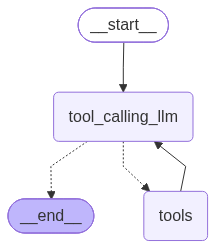

In [83]:
graph

In [84]:
response = graph.invoke({"messages": [{"role": "user", "content": "What is the recent AI news and then multiply 5 by 10?"}]})
for n in response["messages"]:
    n.pretty_print()

================================ Human Message =================================

What is the recent AI news and then multiply 5 by 10?
================================== Ai Message ==================================
Tool Calls:
  tavily_search (fc_6e7faebc-903d-4d46-a8cf-40a4d32265df)
 Call ID: fc_6e7faebc-903d-4d46-a8cf-40a4d32265df
  Args:
    query: recent AI news
    search_depth: basic
    time_range: day
    topic: news
================================= Tool Message =================================
Name: tavily_search

{"query": "recent AI news", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://www.theguardian.com/technology/2026/aug/23/openai-cyber-attacks-threat-chris-lehane", "title": "OpenAI leader warns of threat of 'persistent' AI cyber-attacks", "content": "The Hugging Face incident, and similar recent cases admitted by other AI companies, have sparked increasing claims from safety experts that AI companies have behaved recklessly a

In [85]:
#Adding memory to the Agentic Graph.

response = graph.invoke({"messages": [{"role": "user", "content": "hello This is Pavan?"}]})
for n in response["messages"]:
    n.pretty_print()

================================ Human Message =================================

hello This is Pavan?
================================== Ai Message ==================================

Hello Pavan! How can I help you today?


In [86]:
response = graph.invoke({"messages": [{"role": "user", "content": "What is my name?"}]})
for n in response["messages"]:
    n.pretty_print()

================================ Human Message =================================

What is my name?
================================== Ai Message ==================================

I don’t have that information. What would you like me to call you?


In [87]:
#Adding memory to the graph help us to remember the previous conversation and context. This allows the chatbots to provide more personalized and relevant responses based on the user's history and preferences.

#ReACT agent architecture.
'''
1) ACT
2) Observe
3) Reason
'''

from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode, tools_condition
from langgraph.checkpoint.memory import MemorySaver

memory = MemorySaver()


# Node definition
def tool_calling_llm(state: State):
    return {
        "messages": [
            llm_with_tool.invoke(state["messages"])
        ]
    }


# Create graph
builder = StateGraph(State)


# Add nodes
builder.add_node("tool_calling_llm", tool_calling_llm)
builder.add_node("tools", ToolNode(tools))


# START → LLM
builder.add_edge(START, "tool_calling_llm")


# LLM → either tools OR END
builder.add_conditional_edges(
    "tool_calling_llm",
    tools_condition,
)


# Tools → LLM
builder.add_edge("tools", "tool_calling_llm")


# Compile
graph = builder.compile(checkpointer = memory)


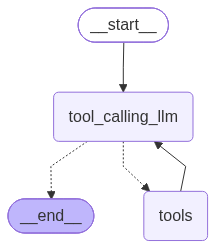

In [88]:
graph

In [89]:
config = {"configurable":{"thread_id":"1"}}

graph.invoke({"messages": [{"role": "user", "content": "Hi my name is Pavan"}]}, config=config)

response

{'messages': [HumanMessage(content='What is my name?', additional_kwargs={}, response_metadata={}, id='cc39e072-55d9-4656-9358-b92947bca645'),
  AIMessage(content='I don’t have that information. What would you like me to call you?', additional_kwargs={'reasoning_content': "We don't know the user's name. We should ask."}, response_metadata={'token_usage': {'completion_tokens': 37, 'prompt_tokens': 356, 'total_tokens': 393, 'completion_time': 0.038163031, 'completion_tokens_details': {'reasoning_tokens': 12}, 'prompt_time': 0.02021112, 'prompt_tokens_details': None, 'queue_time': 0.046135124, 'total_time': 0.058374151}, 'model_name': 'openai/gpt-oss-20b', 'system_fingerprint': 'fp_80501ff3a1', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--01a032e4-6064-7d82-b03f-b0c88b597c6c-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 356, 'output_tokens': 37, 'total_tokens': 393, 'output_token_details': {'reas

In [91]:
config = {"configurable":{"thread_id":"1"}}
response = graph.invoke({"messages":[{"role":"user","content":"Hi my name is Pavan"}]}, config=config)


In [92]:
response

{'messages': [HumanMessage(content='Hi my name is Pavan', additional_kwargs={}, response_metadata={}, id='602b6195-d489-4443-824e-7e1e9bbc1dff'),
  AIMessage(content='Hello Pavan! 👋 How can I help you today?', additional_kwargs={'reasoning_content': 'The user just says "Hi my name is Pavan". We need to respond appropriately. It\'s a greeting. We should respond warmly, maybe ask how we can help. No need to use tools.'}, response_metadata={'token_usage': {'completion_tokens': 63, 'prompt_tokens': 357, 'total_tokens': 420, 'completion_time': 0.091050092, 'completion_tokens_details': {'reasoning_tokens': 41}, 'prompt_time': 0.01742118, 'prompt_tokens_details': None, 'queue_time': 0.284521129, 'total_time': 0.108471272}, 'model_name': 'openai/gpt-oss-20b', 'system_fingerprint': 'fp_38cbe36ff0', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--01a032ec-a07c-7aa1-a219-28b77694c696-0', tool_calls=[], invalid_tool_calls=[], usage_met

In [93]:
response["messages"][-1].content

'Nice to meet you again, Pavan! How’s your day going? If there’s anything you’d like to chat about or any question you have, just let me know.'

In [94]:
response = graph.invoke({"messages":[{"role":"user","content":"Hey What is my name?"}]}, config = config)
print(response["messages"][-1].content)


You’re Pavan!


In [95]:
response = graph.invoke({"messages":[{"role":"user","content":"Do you remember my name?"}]}, config = config)
print(response["messages"][-1].content)


Yes, your name is Pavan.


In [96]:
#Streaming the response from the graph.

from langgraph.checkpoint.memory import MemorySaver
memory = MemorySaver()

In [97]:
def superbot(state: State):
    return {
        "messages": [llm.invoke(state["messages"])]
    }

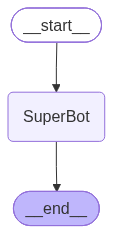

In [98]:
graph = StateGraph(State)

#Node.
graph.add_node("SuperBot",superbot)

#Edges.
graph.add_edge(START, "SuperBot")
graph.add_edge("SuperBot", END)

graph_builder = graph.compile(checkpointer=memory)

#Display.
graph_builder

In [99]:
#Invocation.

config = {"configurable":{"thread_id":"1"}}
graph_builder.invoke({"messages":"Hi, My name is pavan and i like to play cricket"}, config)

{'messages': [HumanMessage(content='Hi, My name is pavan and i like to play cricket', additional_kwargs={}, response_metadata={}, id='630be9ab-5232-4190-964e-949cb1d401a5'),
  AIMessage(content='Hey Pavan! 👋🏼\n\nNice to meet you—cricket is a fantastic sport! What’s your favorite team or player? And do you usually play as a batsman, bowler, or all‑rounder? I’d love to hear more about your cricket adventures!', additional_kwargs={'reasoning_content': 'User: "Hi, My name is pavan and i like to play cricket". They just introduced themselves. We should respond in a friendly manner, acknowledging. Also ask about cricket preferences: favorite team, position, etc. Possibly mention that we can talk about cricket. Let\'s respond.'}, response_metadata={'token_usage': {'completion_tokens': 125, 'prompt_tokens': 84, 'total_tokens': 209, 'completion_time': 0.13440591, 'completion_tokens_details': {'reasoning_tokens': 58}, 'prompt_time': 0.003962487, 'prompt_tokens_details': None, 'queue_time': 0.306

In [ ]:
#Streaming.

"""
Methods: stream and stream()

> These methods are sync and async methods for streaming back results.

Additional parameters in streaming modes for graph state.

>Values : This streams the full state of the graph after each node is called.
>Updates: This streams updates to the state of the graph after each node is called.

"""


In [100]:
#Invocation.

config = {"configurable":{"thread_id":"3"}}
for chunk in graph_builder.stream({"messages":"Hi, My name is pavan and i like to play cricket"}, config, stream_mode="updates"):
    print(chunk)
    

{'SuperBot': {'messages': [AIMessage(content='Hello Pavan! 👋 It’s great to meet someone who loves cricket. Do you play any particular position—batsman, bowler, or all‑rounder? Or maybe you’re a big fan of a specific team or player? Let me know what you’d like to chat about—whether it’s tips, recent matches, or just fun cricket trivia!', additional_kwargs={'reasoning_content': 'User says: "Hi, My name is pavan and i like to play cricket". We need to respond appropriately. The user is greeting and telling us their name and interest. We can respond politely, ask about cricket. The user hasn\'t asked a question. We should greet back, confirm name, ask about cricket. Also mention we can discuss cricket or other topics. Let\'s do that.'}, response_metadata={'token_usage': {'completion_tokens': 163, 'prompt_tokens': 84, 'total_tokens': 247, 'completion_time': 0.172272073, 'completion_tokens_details': {'reasoning_tokens': 79}, 'prompt_time': 0.004745123, 'prompt_tokens_details': None, 'queue_t

In [101]:
#Invocation.

config = {"configurable":{"thread_id":"3"}}
for chunk in graph_builder.stream({"messages":"Hi, My name is pavan and i like to play cricket"}, config, stream_mode="values"):
    print(chunk)
    

{'messages': [HumanMessage(content='Hi, My name is pavan and i like to play cricket', additional_kwargs={}, response_metadata={}, id='be646f39-7d17-4180-98f7-09b48cdcd392'), AIMessage(content='Hello Pavan! 👋 It’s great to meet someone who loves cricket. Do you play any particular position—batsman, bowler, or all‑rounder? Or maybe you’re a big fan of a specific team or player? Let me know what you’d like to chat about—whether it’s tips, recent matches, or just fun cricket trivia!', additional_kwargs={'reasoning_content': 'User says: "Hi, My name is pavan and i like to play cricket". We need to respond appropriately. The user is greeting and telling us their name and interest. We can respond politely, ask about cricket. The user hasn\'t asked a question. We should greet back, confirm name, ask about cricket. Also mention we can discuss cricket or other topics. Let\'s do that.'}, response_metadata={'token_usage': {'completion_tokens': 163, 'prompt_tokens': 84, 'total_tokens': 247, 'comple

In [102]:
#Invocation.

config = {"configurable":{"thread_id":"4"}}
for chunk in graph_builder.stream({"messages":"Hi, My name is pavan and i like to play cricket"}, config, stream_mode="updates"):
    print(chunk)
    

{'SuperBot': {'messages': [AIMessage(content='Hello Pavan! 👋 It’s great to meet someone who loves cricket. How long have you been playing? Do you have a favorite player or team? Let me know what you enjoy most about the game!', additional_kwargs={'reasoning_content': 'We need to respond. The user says "Hi, My name is pavan and i like to play cricket". We should greet, confirm name, maybe ask about cricket. There\'s no policy violation. Just friendly chat.'}, response_metadata={'token_usage': {'completion_tokens': 97, 'prompt_tokens': 84, 'total_tokens': 181, 'completion_time': 0.15409097, 'completion_tokens_details': {'reasoning_tokens': 45}, 'prompt_time': 0.004353157, 'prompt_tokens_details': None, 'queue_time': 0.30591657, 'total_time': 0.158444127}, 'model_name': 'openai/gpt-oss-20b', 'system_fingerprint': 'fp_851252edc2', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--01a03302-9bb1-7200-85e8-ff7be02efe15-0', tool_call

In [103]:
for chunk in graph_builder.stream({"messages":"I also likes to play kabaddi"}, config, stream_mode="values"):
    print(chunk)

{'messages': [HumanMessage(content='Hi, My name is pavan and i like to play cricket', additional_kwargs={}, response_metadata={}, id='6a4f9ca3-1308-4146-98af-16249f94f778'), AIMessage(content='Hello Pavan! 👋 It’s great to meet someone who loves cricket. How long have you been playing? Do you have a favorite player or team? Let me know what you enjoy most about the game!', additional_kwargs={'reasoning_content': 'We need to respond. The user says "Hi, My name is pavan and i like to play cricket". We should greet, confirm name, maybe ask about cricket. There\'s no policy violation. Just friendly chat.'}, response_metadata={'token_usage': {'completion_tokens': 97, 'prompt_tokens': 84, 'total_tokens': 181, 'completion_time': 0.15409097, 'completion_tokens_details': {'reasoning_tokens': 45}, 'prompt_time': 0.004353157, 'prompt_tokens_details': None, 'queue_time': 0.30591657, 'total_time': 0.158444127}, 'model_name': 'openai/gpt-oss-20b', 'system_fingerprint': 'fp_851252edc2', 'service_tier'

In [109]:
config = {
    "configurable": {
        "thread_id": "5"
    }
}

async for event in graph_builder.astream_events(
    {
        "messages": [
            ("user", "Hi, my name is Pavan and I like to play cricket")
        ]
    },
    config,
    version="v2"
):
    print(event)

{'event': 'on_chain_start', 'data': {'input': {'messages': [('user', 'Hi, my name is Pavan and I like to play cricket')]}}, 'name': 'LangGraph', 'tags': [], 'run_id': '01a0330b-c035-7081-b1ad-f8e6f630ca3e', 'metadata': {'thread_id': '5', 'ls_integration': 'langgraph'}, 'parent_ids': []}
{'event': 'on_chain_start', 'data': {'input': {'messages': [HumanMessage(content='Hi, my name is Pavan and I like to play cricket', additional_kwargs={}, response_metadata={}, id='9cd9d43d-434f-4eaf-bccb-b6890acb64fe')]}}, 'name': 'SuperBot', 'tags': ['graph:step:1'], 'run_id': '01a0330b-c038-7b23-a2ce-68596e824510', 'metadata': {'thread_id': '5', 'ls_integration': 'langgraph', 'langgraph_step': 1, 'langgraph_node': 'SuperBot', 'langgraph_triggers': ('branch:to:SuperBot',), 'langgraph_path': ('__pregel_pull', 'SuperBot'), 'langgraph_checkpoint_ns': 'SuperBot:08c89c4b-34c3-fe97-80f8-71cfa71ae092'}, 'parent_ids': ['01a0330b-c035-7081-b1ad-f8e6f630ca3e']}
{'event': 'on_chat_model_start', 'data': {'input': 

In [ ]:
#Human in the loop Implementation.

